## K-Means

### Outline
- 简介
- 推导过程
- 簇中心为什么是均值
- K-means的收敛性与局部最优
- k的选择
- k-means优缺点
- sklearn实战

### 简介
k-means是属于无监督学习里的一种聚类算法，不需要提供标签，而是根据样本之间的相似程度，将数据划分成K个簇。用物以类聚人与群分这句可以很好的总结。这个算法就是是把那些离得近的点归为一类，这近通常指的欧式距离。


In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris

### 推导过程
k-means就是找到簇质点将距离近的样本划分为一类，它具体是这样操作的
1. 初始化k个簇中心（可以从数据点中随机选取；也可以使用k-means++初始化方法，它会通过一种合理的概率方式选择出始中心，使初始中心尽量分散）
2. 将每个样本分配给距离最近的簇中心
3. 根据上述分配好的簇重新计算簇中心
4. 在重复2，3操作直到满足下降幅度足够小，或者达到最大迭代次数

In [ ]:
def dispatch(X,m_u,k):
    m,n=X.shape
    # 每列为样本点到不同集群u的距离
    distance=np.zeros((m,k))
    for i,u in enumerate(m_u):
        distance[:,i]=np.linalg.norm(X-u,axis=1)
    return np.argmin(distance,axis=1)

def new_mu(X,cluster,K):
    m, n = X.shape
    new_centroids = np.zeros((K, n))
    for k in range(K):
        points = X[cluster == k]
        if len(points)>0:
            new_centroids[k]=np.mean(points,axis=0)
        else:
            new_centroids[k] = X[np.random.choice(m)]
        
    return new_centroids

def k_means_(X,n,k):
    m_u=np.random.permutation(X)[:k]
    for i in range(n):
        cluster=dispatch(X,m_u,k)
        m_u=new_mu(X,cluster,k)
    return cluster


### 簇中心为什么是均值
这个算法为什么成立，找到合适簇质点
$$
J(C^{(1)},C^{(2)},...,C^{(k)},u_1,...,u_k)=\frac{1}{m} \sum_{i=1}^m ||x^{(i)}-u_{ci}||^2
$$
- $C^{(k)}$ k个分类集群
- $u_c^{(i)}$ 样本i被所属簇中心

上面这个式子就是聚类算法的优化目标函数，给定样本X找到K个簇，让每个簇里的样本点到簇中心距离最小化。这里x是已知数，我们要在K个簇分别挑选合适$u_c$使J变小，换个问题簇的均值为什么能使j缩小。J分别由k个簇的样本到簇中心的距离和组成

现在固定只看单独某个簇$J_
k= \arg\min_k \Vert{}x^{(i)} - \mu_k\Vert{}^2$，
将其展开
$$J_k = \sum_{i \in C_k} (x^{(i)} - \mu_k)^T (x^{(i)} - \mu_k) = \sum_{i \in C_k} \left( (x^{(i)})^T x^{(i)} - 2 \mu_k^T x^{(i)} + \mu_k^T \mu_k \right)$$

对其计算一阶梯度：
$$\nabla_{\mu_k} J_k = \sum_{i \in C_k} \left( -2 x^{(i)} + 2 \mu_k \right) = -2 \sum_{i \in C_k} x^{(i)} + 2 |C_k|  \mu_k$$

> |C_k| 是 簇中样本个数，是$\sum_{i \in C_k}$化简

令梯度等于零向量 
$$
 \mu_k =\frac{1}{|C_k| }\sum_{i \in C_k} x^{(i)} 
$$
计算二阶导数：$$\nabla^2_{\mu_k} J_k(\mu_k) = 2 |C_k| $$
因为|C_k| > 0 所以 $J_k(\mu_k)$ 是凸函数。这个驻点就是一个全局唯一最小值
$$
 \mu_k =\frac{1}{|C_k| }\sum_{i \in C_k} x^{(i)} 
$$

> K-means -> 最小化簇平方距离  -> 交替优化
- 固定中心 给样本重新分配簇
- 固定簇划分 用均值更新簇中心
- 不断交替 目标函数下降
- 收敛到一个局部最优

### K-means的收敛性与局部最优
但需要注意，这并不意味着它找到全局最优，因为k-means整体上有两个变量，一个$C_k$划分簇，一个是$u_k$簇中心。k-means的过程是交替进行(Lloyd)，固定簇中心$u_k$使样本分配到最近簇，固定簇划分$C_k$重新计算每个簇的均值作为新的簇中心，每一步让目标函数不断递减，从而收敛到局部最优。但是k-means不保证找到全局最优

### k值该怎么确定
k-means最大的问题不知道需要几个簇，所以需要人为指定
- 肘部法制
计算K=1,2,3..对应的J的值，然后画出k-J，因为K越多，簇划分越细，J 几乎一定会不断下降，因此不能简单选择 J 最小的 K，而是寻找下降速度明显变缓的肘部。

- 轮廓系数 

- 根据实际业务选择
> todo


### k-means优缺点
优点
1. 简单容易理解
2. 计算效率高，适合较大规模数据
3. 对高维数据也可以使用


缺点
1. 必须提前指定K
2. 初始化敏感
3. 对尺度敏感，所以需要对数据标准化
4. 对异常值敏感，离群点会影响均值，从而影响中心 （异常检车预处理数据）
5. 只适合于球状的簇，对于其他形状（月牙，环形）效果就不好 -todo有其他方法


### sklearn实战
上面已经将了k-means的相关实现，现在来看看sklearn里的关于它一些配置参数
- init 初始化参数，对应的怎么选择最初的簇中心，默认k-means++,随机选择参数randoms
- n_init 使用不同的初始化允许，选择最后计算误差项最小的那次，'auto' 为自动
- max_iter 一次初始化情况下，执行多少轮替换更新
- tol 通过比较连续两轮中目标J的变化，如果小于该值就停止
- ramdom_state 控制随机初始化，使训练过程具有可重复性
- algorithm lloyd/elkan，lloyd是上面所讲的经典的交替计算法，elkan则是它的优化，简单认为计算更快，但会使用更多内存
- verbose 详细程度输出

训练后属性
- 查看簇中心 `model.named_steps["kmeans"].cluster_centers_`
- 查看样本所属簇 `model.named_steps["kmeans"].labels_`
- 查看样本目标函数 `model.named_steps["kmeans"].inertia_`

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
iris=load_iris()
X=iris['data'][:,[0,1]]
target=iris['target']
kmeans=KMeans(n_clusters=2)
scaler=StandardScaler()
pipe=make_pipeline(scaler,kmeans)
model=pipe.fit(X)

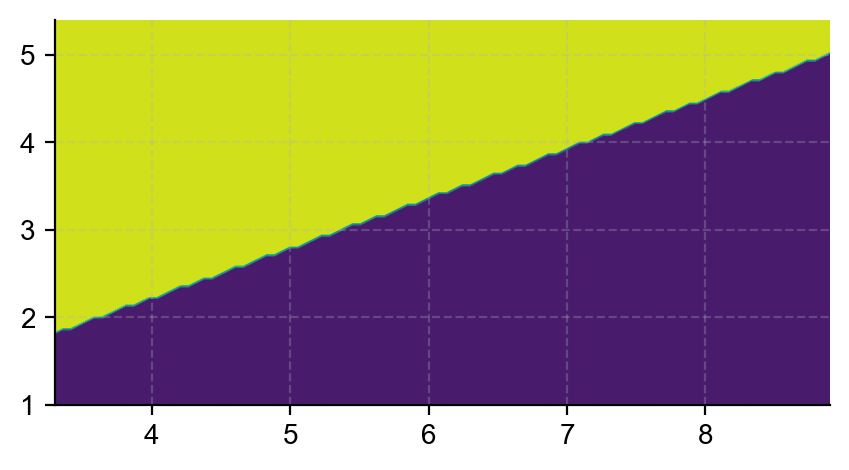

In [23]:
from sklearn.inspection import DecisionBoundaryDisplay
fig,ax =plt.subplots()
DecisionBoundaryDisplay.from_estimator(model,X,response_method='predict',ax=ax)

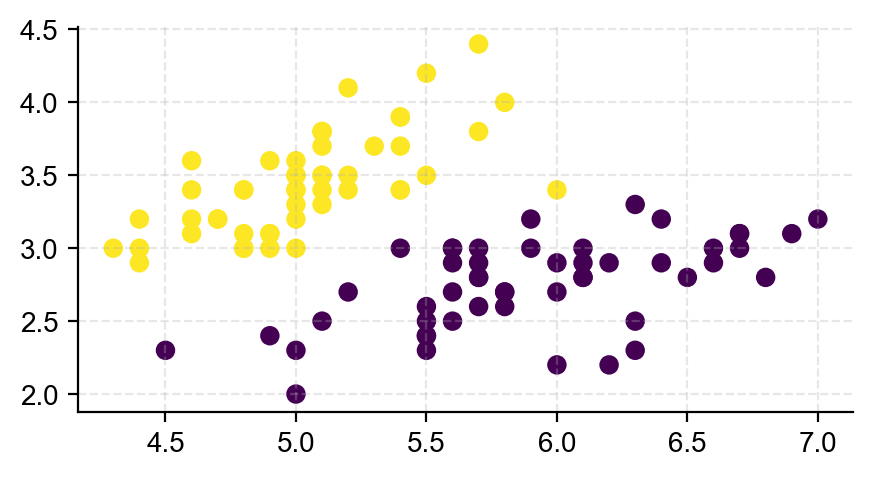

In [28]:
data=X[:100]
y=model.predict(data)
plt.scatter(data[:,0],data[:,1],c=y)